# BrushCue Example: Cartoon Filter

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/cartoon_filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/cartoon-filter

In [ ]:
!pip install brushcue

[wgpu] using backend Vulkan — adapter 'NVIDIA GeForce RTX 5070' (DiscreteGpu), driver 'NVIDIA'


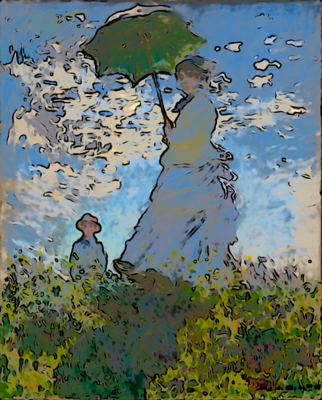

In [1]:
import io
from PIL import Image

import brushcue as bc

input_image = bc.Composition.monet_women_with_parasol()
bounds = input_image.bounds()
work_scale = (1100.0 / bounds.width()).min((1100.0 / bounds.height())).min(1.0)
small = input_image.transform(
    bc.Transform2.identity().scale(bc.Vector2f.from_components(work_scale, work_scale))
)
small_flat = small.median(3).median(3).median(2)
small_bounds = small.bounds()
to_full = bc.Transform2.identity().scale(
    bc.Vector2f.from_components((1.0 / work_scale), (1.0 / work_scale))
)
ink = (
    small_flat.gaussian_blur(0.7)
    .spacial_effect_shader(
        "let lo = image_bounds.xy + vec2<f32>(0.5);\nlet hi = image_bounds.zw - vec2<f32>(0.5);\nlet k = vec3<f32>(0.2126, 0.7152, 0.0722);\nlet tl = dot(sample(clamp(position + vec2<f32>(-w, -w), lo, hi)).rgb, k);\nlet t = dot(sample(clamp(position + vec2<f32>(0.0, -w), lo, hi)).rgb, k);\nlet tr = dot(sample(clamp(position + vec2<f32>(w, -w), lo, hi)).rgb, k);\nlet l = dot(sample(clamp(position + vec2<f32>(-w, 0.0), lo, hi)).rgb, k);\nlet r = dot(sample(clamp(position + vec2<f32>(w, 0.0), lo, hi)).rgb, k);\nlet bl = dot(sample(clamp(position + vec2<f32>(-w, w), lo, hi)).rgb, k);\nlet b = dot(sample(clamp(position + vec2<f32>(0.0, w), lo, hi)).rgb, k);\nlet br = dot(sample(clamp(position + vec2<f32>(w, w), lo, hi)).rgb, k);\nlet gx = (tr + 2.0 * r + br) - (tl + 2.0 * l + bl);\nlet gy = (bl + 2.0 * b + br) - (tl + 2.0 * t + tr);\nlet edge = smoothstep(0.18, 0.42, length(vec2<f32>(gx, gy)));\nlet v = 1.0 - 0.92 * edge;\nreturn vec4<f32>(v, v, v, 1.0);",
        "",
        3.0,
        bc.Dictionary.create().add("w", 2.0).add("image_bounds", small_bounds),
        bc.ColorRepresentation.srgb(),
    )
    .transform(to_full)
    .gaussian_blur((0.5 / work_scale))
    .crop(bounds)
)
flat = small_flat.transform(to_full).crop(bounds)
shaded = flat.color_transformer_shader(
    "let bands = 5.0;\nlet x = clamp(input.x, 0.0, 1.0) * bands;\nlet f = fract(x);\nlet stepped = (floor(x) + smoothstep(0.3, 0.7, f)) / bands;\nlet l = mix(input.x, stepped, 0.8);\nlet ab = input.yz * 1.45;\nreturn vec4<f32>(l, ab.x, ab.y, input.w);",
    "",
    bc.ColorRepresentation.oklab_a(),
    bc.ColorRepresentation.oklab_a(),
    bc.Dictionary.create(),
)
filtered = ink.blend_multiply(shaded, bc.Transform2.identity()).crop(bounds)
strength = 1.0
graph = (
    filtered.opacity_scales(strength)
    .blend_alpha(input_image, bc.Transform2.identity())
    .crop(bounds)
)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
